### Final Team Project: Music Genre and Composer Classification Using Deep Learning
##### Name: Jasmine Duong, Emmanuel Sadek, Carlo Casella
##### Date: 17 July 2026

##### Introduction
Music is a form of art that is ubiquitous and has a rich history. Different composers have created music with their unique styles and compositions. However, identifying the composer of a particular piece of music can be a challenging task, especially for novice musicians or listeners. The proposed project aims to use deep learning techniques to identify the composer of a given piece of music accurately.

##### Objective
The primary objective of this project is to develop a deep learning model that can predict the composer of a given musical score accurately. The project aims to accomplish this objective by using two deep learning techniques: Long Short-Term Memory (LSTM) and Convolutional Neural Network (CNN).

Dataset
The project will use a dataset consisting of musical scores from various composers. 

The dataset contains the midi files of compositions from well-known classical composers like Bach, Beethoven, Chopin, and Mozart. The dataset should be labeled with the name of the composer for each score. Please only do your prediction only for below composers, therefore you need to select the required composers from the given dataset above.

1-Bach
2-Beethoven
3-Chopin
4-Mozart

In [2]:
!pip install pretty_midi music21 torch torchvision torchaudio scikit-learn kagglehub

import os
import shutil
import glob
import random
import numpy as np

import pretty_midi
from music21 import converter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


     ---------------------------------------- 0.0/5.6 MB ? eta -:--:--
     ------------- -------------------------- 1.8/5.6 MB 20.0 MB/s eta 0:00:01
     ---------------------------------------- 5.6/5.6 MB 32.8 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/20.1 MB ? eta -:--:--
   ----- ---------------------------------- 2.9/20.1 MB 94.7 MB/s eta 0:00:01
   -------------------- ------------------- 10.2/20.1 MB 24.8 MB/s eta 0:00:01
   ------------------------------ --------- 15.5/20.1 MB 25.0 MB/s eta 0:00:01
   ---------------------------------------- 20.1/20.1 MB 25.4 MB/s  0:00:00
   ---------------------------------------- 0.0/4.2 MB ? eta -

#### 1. Dataset filtering (only Bach, Beethoven, Chopin, Mozart)

In [3]:
import kagglehub
path = kagglehub.dataset_download("blanderbuss/midi-classic-music")
print("Path to dataset files:", path)


100%|██████████| 68.2M/68.2M [00:01<00:00, 44.9MB/s]

Extracting files...


Path to dataset files: C:\Users\carlo\.cache\kagglehub\datasets\blanderbuss\midi-classic-music\versions\1


In [4]:
SOURCE_DIR = path  # from kagglehub
FILTERED_DIR = "filtered_composers"
os.makedirs(FILTERED_DIR, exist_ok=True)

TARGET_COMPOSERS = ["Bach", "Beethoven", "Chopin", "Mozart"]

for comp in TARGET_COMPOSERS:
    os.makedirs(os.path.join(FILTERED_DIR, comp), exist_ok=True)

for root, dirs, files in os.walk(SOURCE_DIR):
    for file in files:
        if file.lower().endswith((".mid", ".midi")):
            full_path = os.path.join(root, file)
            lower_root = root.lower()
            lower_file = file.lower()
            for comp in TARGET_COMPOSERS:
                if comp.lower() in lower_root or comp.lower() in lower_file:
                    dest_dir = os.path.join(FILTERED_DIR, comp)
                    shutil.copy(full_path, dest_dir)
                    break

#### 2. Exploratory Data Analysis

In [5]:
import os
import pretty_midi
import numpy as np
import matplotlib.pyplot as plt

composer_counts = {c: len(os.listdir(os.path.join(FILTERED_DIR, c))) for c in TARGET_COMPOSERS}
composer_counts


{'Bach': 1049, 'Beethoven': 213, 'Chopin': 138, 'Mozart': 259}

##### 2.1 Count files per composer

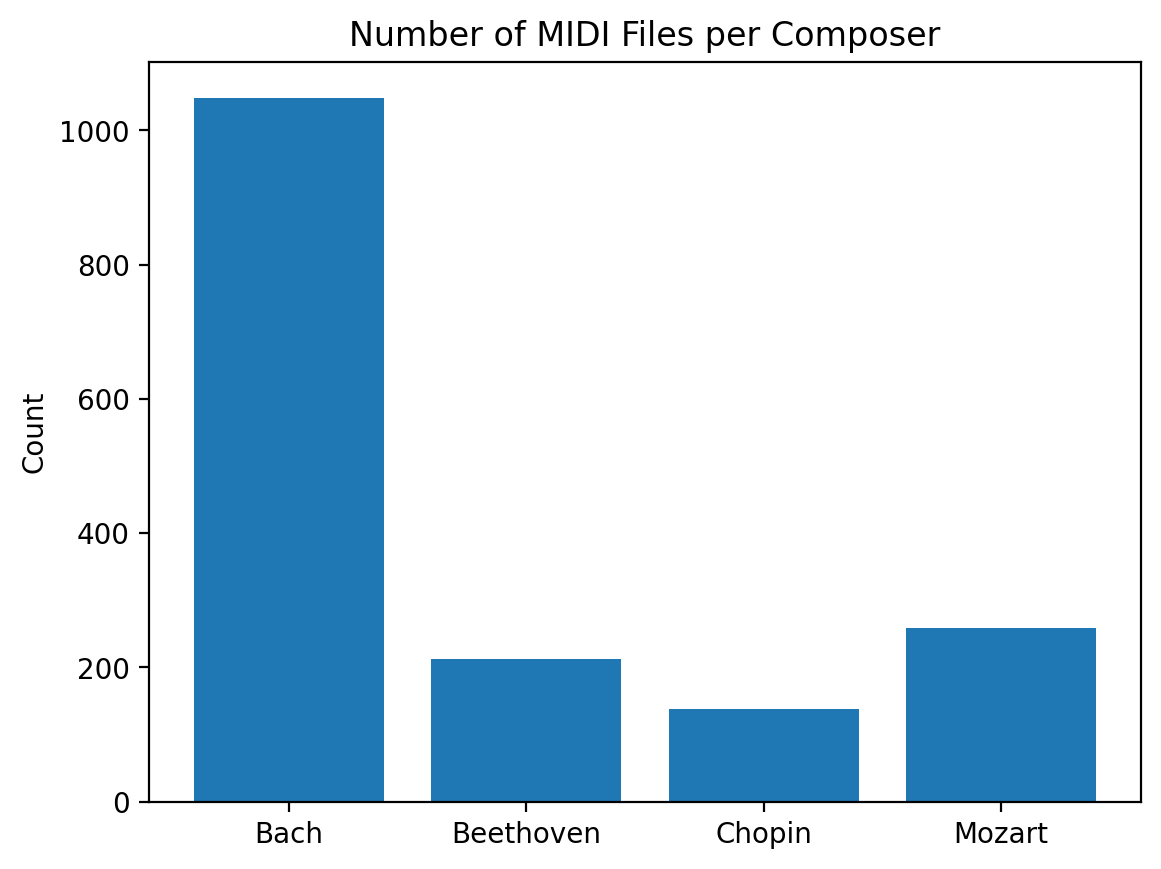

In [6]:
plt.bar(composer_counts.keys(), composer_counts.values())
plt.title("Number of MIDI Files per Composer")
plt.ylabel("Count")
plt.show()

##### 2.2 Extract Global Statistics - Pitch distribution

C:\Users\carlo\anaconda3\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


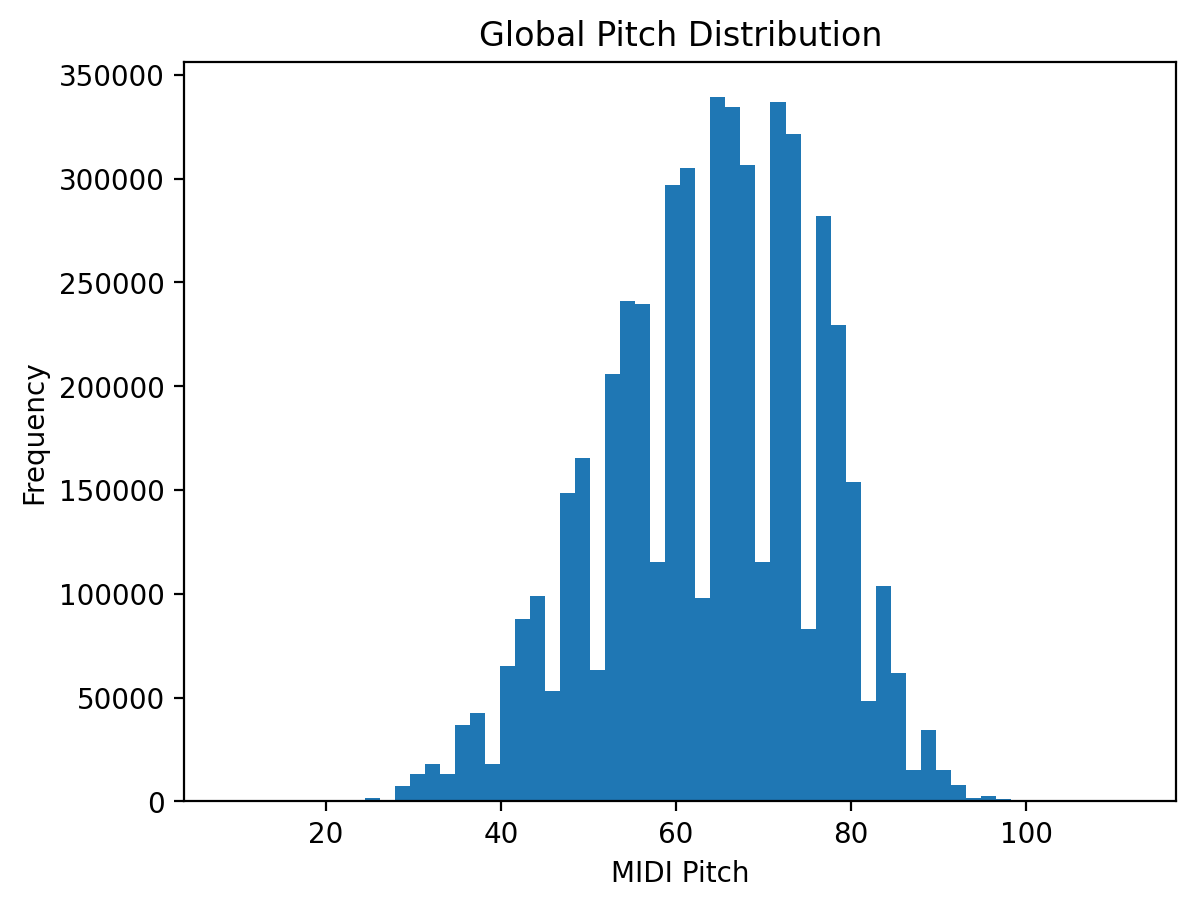

In [7]:
all_pitches = []

for comp in TARGET_COMPOSERS:
    comp_dir = os.path.join(FILTERED_DIR, comp)
    for f in os.listdir(comp_dir):
        try:
            pm = pretty_midi.PrettyMIDI(os.path.join(comp_dir, f))
            for inst in pm.instruments:
                for note in inst.notes:
                    all_pitches.append(note.pitch)
        except:
            continue

plt.hist(all_pitches, bins=60)
plt.title("Global Pitch Distribution")
plt.xlabel("MIDI Pitch")
plt.ylabel("Frequency")
plt.show()

##### 2.3 Extract Global Statistics - Duration distribution

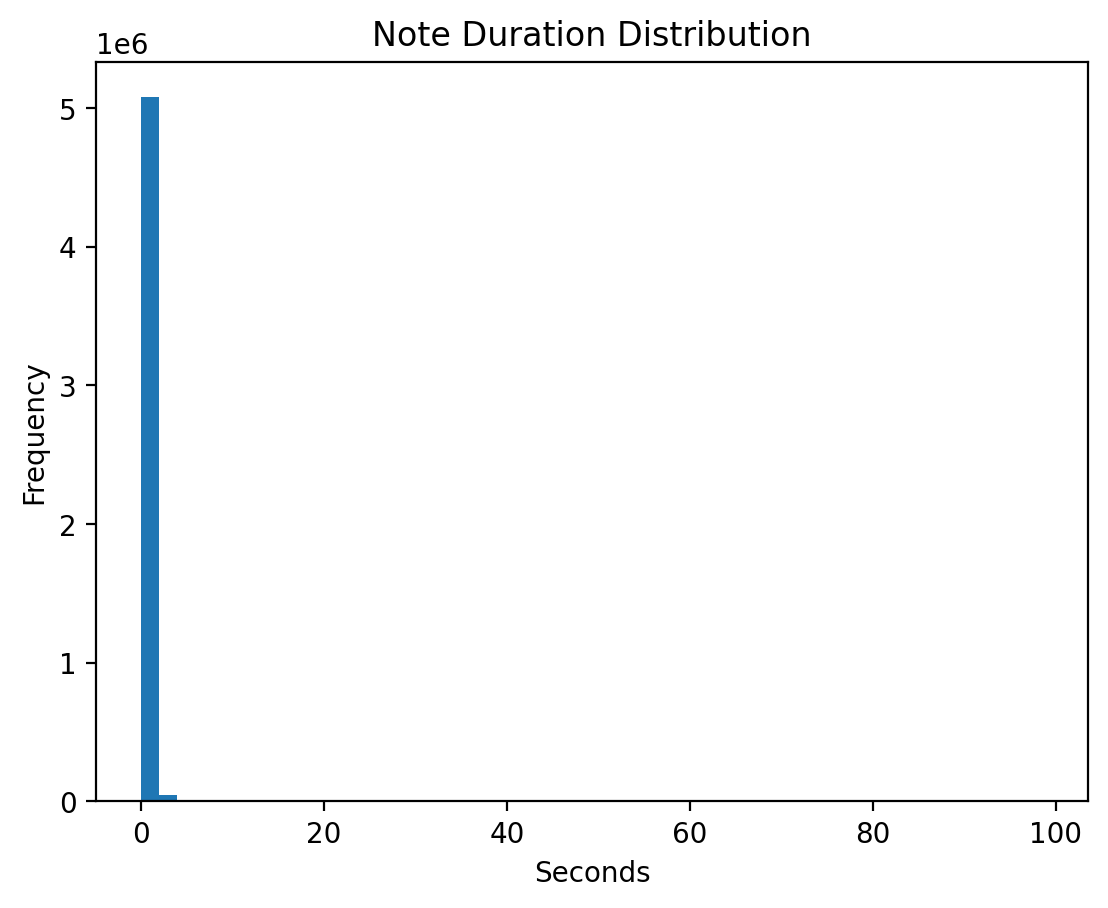

In [8]:
durations = []

for comp in TARGET_COMPOSERS:
    comp_dir = os.path.join(FILTERED_DIR, comp)
    for f in os.listdir(comp_dir):
        try:
            pm = pretty_midi.PrettyMIDI(os.path.join(comp_dir, f))
            for inst in pm.instruments:
                for note in inst.notes:
                    durations.append(note.end - note.start)
        except:
            continue

plt.hist(durations, bins=50)
plt.title("Note Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

##### 2.4 Extract Global Statistics - Tempo distribution

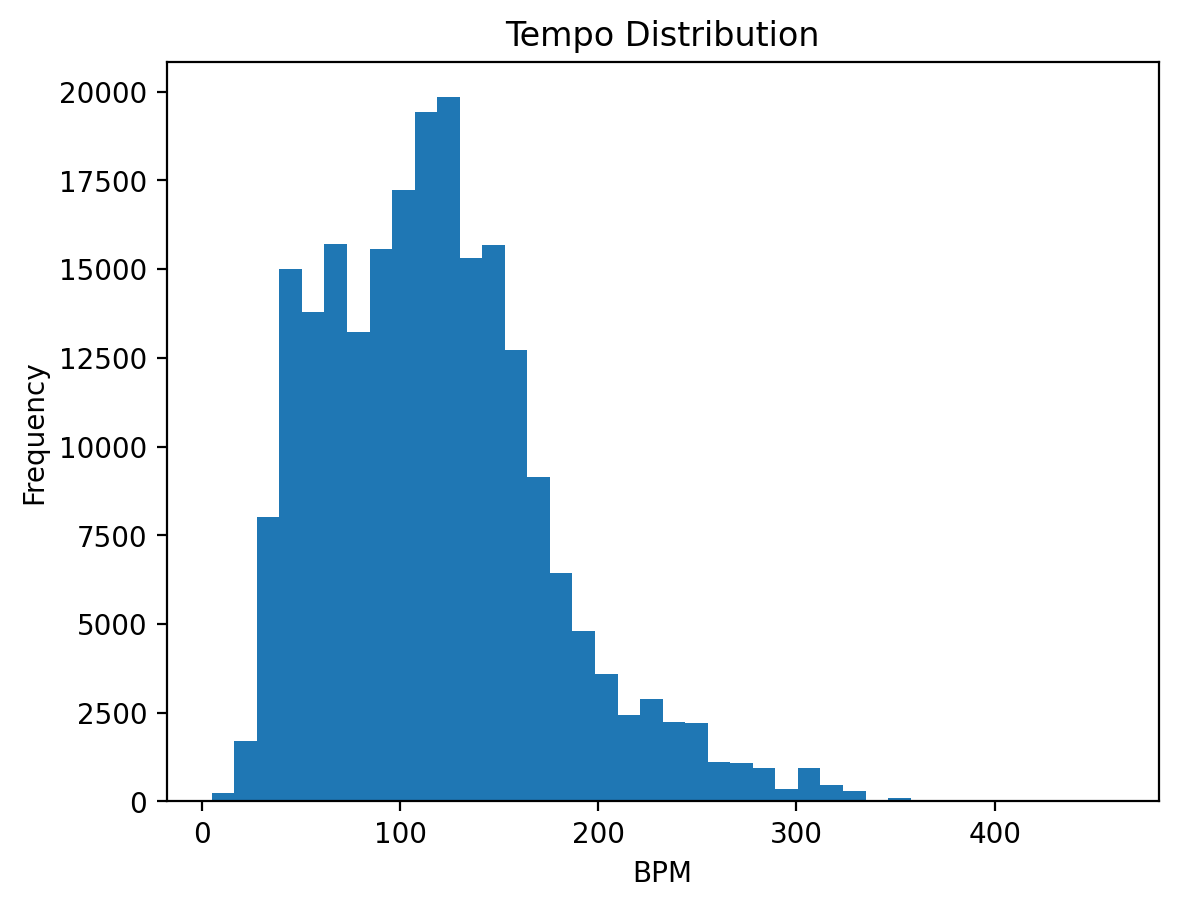

In [9]:
tempos = []

for comp in TARGET_COMPOSERS:
    comp_dir = os.path.join(FILTERED_DIR, comp)
    for f in os.listdir(comp_dir):
        try:
            pm = pretty_midi.PrettyMIDI(os.path.join(comp_dir, f))
            tempos.extend(pm.get_tempo_changes()[1])
        except:
            continue

plt.hist(tempos, bins=40)
plt.title("Tempo Distribution")
plt.xlabel("BPM")
plt.ylabel("Frequency")
plt.show()


##### 2.5 Extract Global Statistics - Sequence length distribution (LSTM)

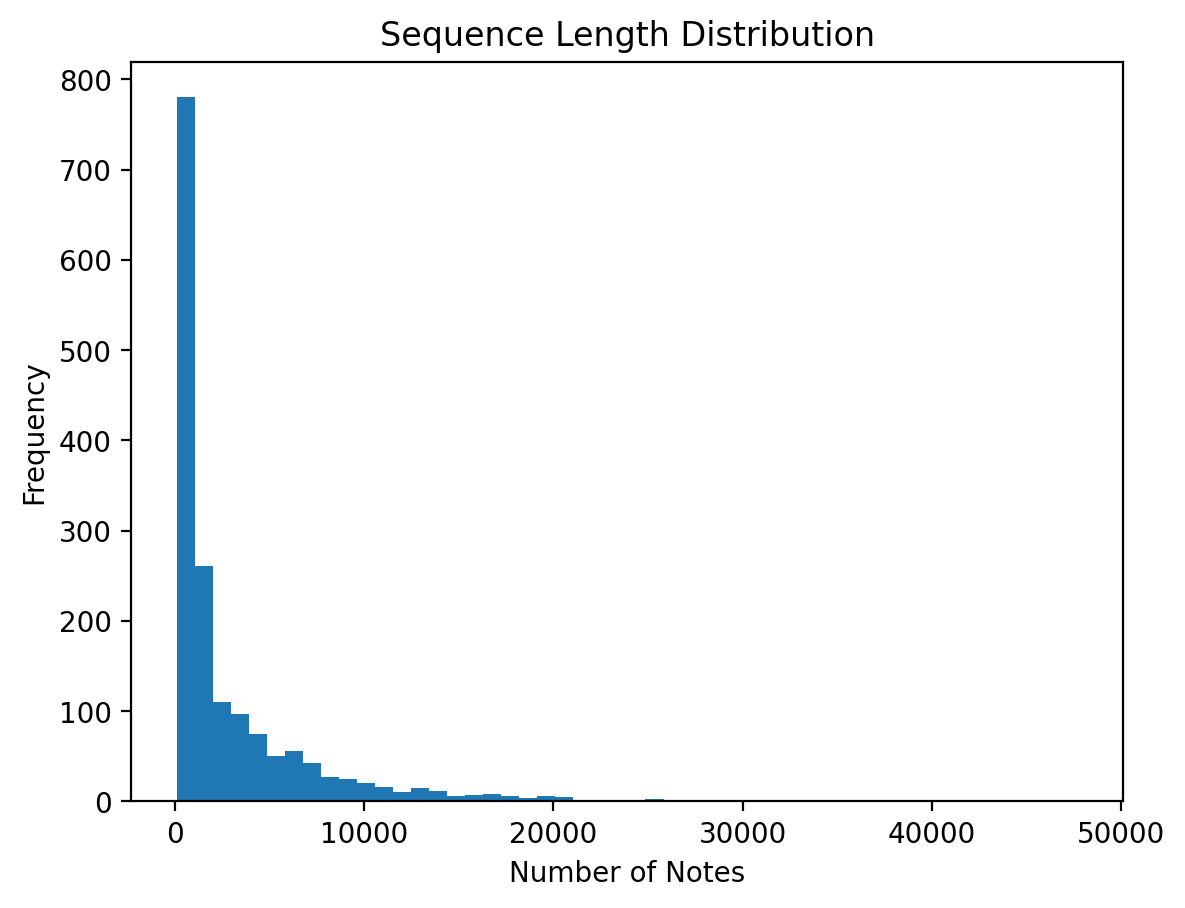

In [10]:
seq_lengths = []

for comp in TARGET_COMPOSERS:
    comp_dir = os.path.join(FILTERED_DIR, comp)
    for f in os.listdir(comp_dir):
        try:
            pm = pretty_midi.PrettyMIDI(os.path.join(comp_dir, f))
            count = sum(len(inst.notes) for inst in pm.instruments)
            seq_lengths.append(count)
        except:
            continue

plt.hist(seq_lengths, bins=50)
plt.title("Sequence Length Distribution")
plt.xlabel("Number of Notes")
plt.ylabel("Frequency")
plt.show()


##### 2.6 Extract Global Statistics - Piano-roll density (for CNN)

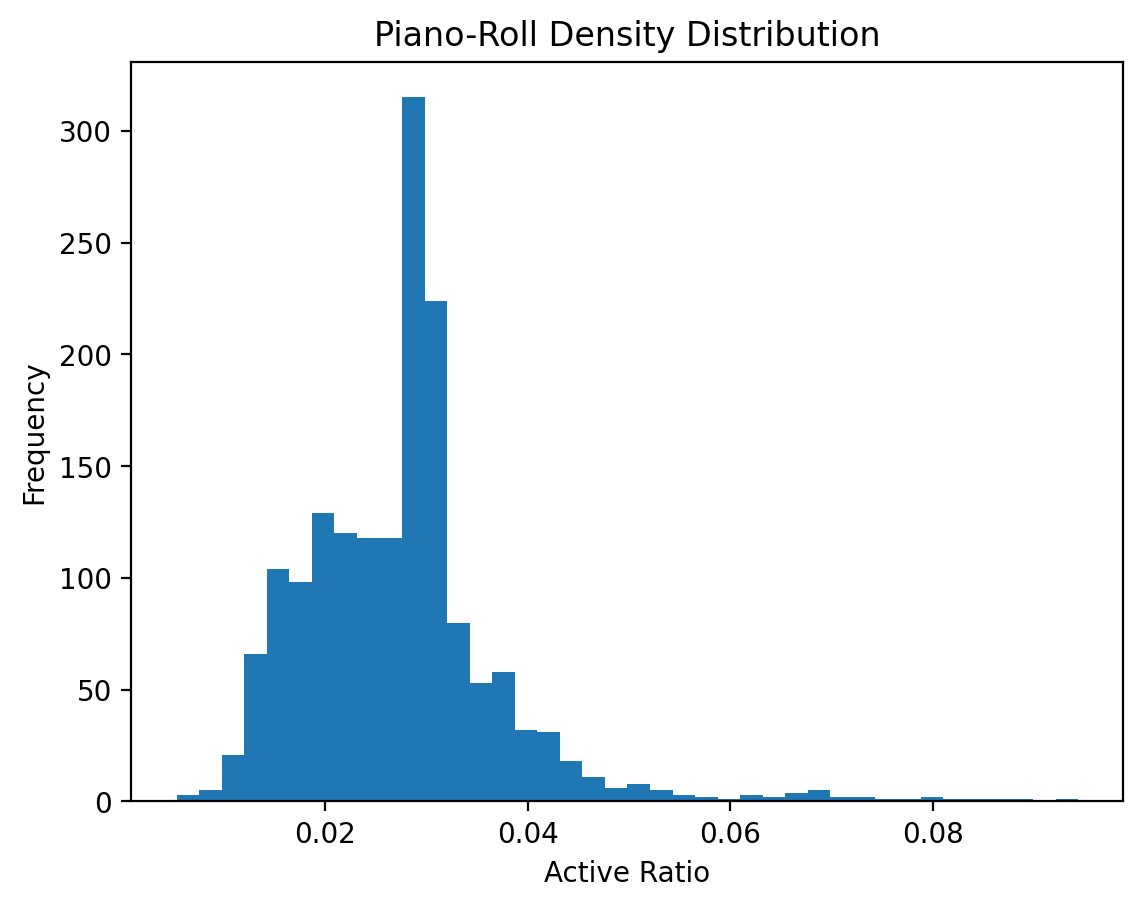

In [11]:
densities = []

for comp in TARGET_COMPOSERS:
    comp_dir = os.path.join(FILTERED_DIR, comp)
    for f in os.listdir(comp_dir):
        try:
            pm = pretty_midi.PrettyMIDI(os.path.join(comp_dir, f))
            pr = pm.get_piano_roll(fs=10)
            densities.append(np.count_nonzero(pr) / pr.size)
        except:
            continue

plt.hist(densities, bins=40)
plt.title("Piano-Roll Density Distribution")
plt.xlabel("Active Ratio")
plt.ylabel("Frequency")
plt.show()

LTSM Model - Input: (max_notes × 3), bidirectional LTSM and fully connected classifier
CNN Model - Input: (1 × pitch_range × frames), 3 convolutional blocks, global average pooling, fully connected classifier.

#### 3. Label encoding and file collection

In [13]:
label_map = {
    "Bach": 0,
    "Beethoven": 1,
    "Chopin": 2,
    "Mozart": 3
}

def collect_files(base_dir):
    files = []
    labels = []
    for comp in TARGET_COMPOSERS:
        comp_dir = os.path.join(base_dir, comp)
        for f in glob.glob(os.path.join(comp_dir, "*.mid")) + glob.glob(os.path.join(comp_dir, "*.midi")):
            files.append(f)
            labels.append(label_map[comp])
    return files, labels

all_files, all_labels = collect_files(FILTERED_DIR)
print("Total files:", len(all_files))

Total files: 1659


#### 4. Data preprocessing & feature extraction
Two represenations are built
LSTM: sequence of note events
CNN: piano-roll matrix

##### 4.1 MIDI to event sequence for LSTM

In [14]:
def midi_to_event_sequence(midi_path, max_notes=500):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
    except Exception:
        return None  # skip problematic files

    events = []
    for instrument in pm.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            pitch = note.pitch
            start = note.start
            end = note.end
            duration = end - start
            velocity = note.velocity
            events.append([pitch, duration, velocity])

    # sort by start time (approximate using note.start)
    # pretty_midi doesn't keep start in note object list order guaranteed
    # but we can sort by start time if needed:
    # events = sorted(events, key=lambda x: x_start)

    if len(events) == 0:
        return None

    # truncate or pad
    if len(events) > max_notes:
        events = events[:max_notes]
    else:
        # pad with zeros
        pad_len = max_notes - len(events)
        events.extend([[0, 0.0, 0]] * pad_len)

    return np.array(events, dtype=np.float32)


##### 4.2 MIDI to piano-roll for CNN

In [15]:
def midi_to_pianoroll(midi_path, fs=10, max_frames=500, pitch_range=(21, 108)):
    # pitch_range: typical piano keys (A0–C8)
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
    except Exception:
        return None

    pr = pm.get_piano_roll(fs=fs)  # shape: (128, T)
    if pr.shape[1] == 0:
        return None

    # crop pitch range
    low, high = pitch_range
    pr = pr[low:high+1, :]  # (num_pitches, T)

    # normalize velocities to [0,1]
    pr = pr / 127.0

    # crop or pad time dimension
    if pr.shape[1] > max_frames:
        pr = pr[:, :max_frames]
    else:
        pad_width = max_frames - pr.shape[1]
        pr = np.pad(pr, ((0, 0), (0, pad_width)), mode='constant')

    return pr.astype(np.float32)


##### 4.3 music21 feature extraction (notes, chords, tempo)
Can be integrated later as additional channels or metadata

In [16]:
def extract_music21_features(midi_path):
    try:
        score = converter.parse(midi_path)
    except Exception:
        return None

    notes = []
    chords = []
    tempos = []

    for el in score.flat:
        if el.isNote:
            notes.append(el.pitch.midi)
        elif el.isChord:
            chords.append([p.midi for p in el.pitches])
        elif el.classes and "MetronomeMark" in el.classes:
            tempos.append(el.number)

    return {
        "notes": notes,
        "chords": chords,
        "tempos": tempos
    }